# 01 — MuJoCo Basics & SO-ARM100 Simulation

Uses the **official TRS SO-ARM100 model** from [MuJoCo Menagerie](https://github.com/chernyadev/mujoco_menagerie/tree/add-so-arm100/trs_so_arm100).

**Before running this notebook**, download the model:
```bash
python download_so_arm100.py
```
This places the model at `models/trs_so_arm100/`.

> All cells run on **CPU only** — no GPU required.

In [27]:
# ── SETUP: Install dependencies ──────────────────────────────────────────────
import subprocess, sys

PKGS = ['mujoco', 'matplotlib', 'numpy', 'ipywidgets']
for pkg in PKGS:
    try:
        __import__(pkg)
        print(f'✓ {pkg}')
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import mujoco
print(f'\nMuJoCo {mujoco.__version__}')

# ── Locate the SO-ARM100 model ────────────────────────────────────────────────
import os

MODEL_DIR   = os.path.join('models', 'trs_so_arm100')
SCENE_XML   = os.path.join(MODEL_DIR, 'scene.xml')
ROBOT_XML   = os.path.join(MODEL_DIR, 'so_arm100.xml')

if not os.path.exists(SCENE_XML):
    print()
    print('Model not found at', SCENE_XML)
    print('   Run:  python download_so_arm100.py  — then re-run this cell.')
else:
    print(f'Model found: {SCENE_XML}')

✓ mujoco
✓ matplotlib
✓ numpy
✓ ipywidgets

MuJoCo 3.6.0
Model found: models/trs_so_arm100/scene.xml


---
## Cell 1 — Load Model & Print Summary

In [28]:
# ── Cell 1: Load SO-ARM100 from Menagerie, print full model summary ───────────
import mujoco
import numpy as np
import os

MODEL_DIR = os.path.join('models', 'trs_so_arm100')
SCENE_XML = os.path.join(MODEL_DIR, 'scene.xml')
ROBOT_XML = os.path.join(MODEL_DIR, 'so_arm100.xml')

# Prefer scene.xml (includes ground + lighting); fall back to robot XML
xml_to_load = SCENE_XML if os.path.exists(SCENE_XML) else ROBOT_XML
print(f'Loading: {xml_to_load}')

model = mujoco.MjModel.from_xml_path(xml_to_load)
data  = mujoco.MjData(model)
mujoco.mj_forward(model, data)

print()
print('╔' + '═'*52 + '╗')
print('║          TRS SO-ARM100 — Model Summary           ║')
print('╠' + '═'*52 + '╣')
print(f'║  nq   (generalized positions)  : {model.nq:<18} ║')
print(f'║  nv   (generalized velocities) : {model.nv:<18} ║')
print(f'║  nbody (rigid bodies)          : {model.nbody:<18} ║')
print(f'║  njnt  (joints)                : {model.njnt:<18} ║')
print(f'║  ngeom (geometries)            : {model.ngeom:<18} ║')
print(f'║  nsite (sites)                 : {model.nsite:<18} ║')
print(f'║  na    (actuators)             : {model.na:<18} ║')
print(f'║  nsensor (sensors)             : {model.nsensor:<18} ║')
print(f'║  nmesh  (meshes)               : {model.nmesh:<18} ║')
print('╠' + '═'*52 + '╣')
print('║  Joint name                     Range (rad/m)   ║')
print('╠' + '═'*52 + '╣')
for i in range(model.njnt):
    j = model.joint(i)
    lo, hi = j.range
    jtype = ['free','ball','slide','hinge'][int(j.type)]
    line  = f'  [{i}] {j.name:<28}  [{lo:+.2f}, {hi:+.2f}]'
    print(f'║{line:<52} ║')
print('╠' + '═'*52 + '╣')
print('║  Actuator                       Gear            ║')
print('╠' + '═'*52 + '╣')
for i in range(model.na):
    a    = model.actuator(i)
    gear = model.actuator_gear[i][0]
    line = f'  [{i}] {a.name:<28}  {gear:>6.1f}'
    print(f'║{line:<52} ║')
print('╚' + '═'*52 + '╝')

print('\nBody tree:')
for i in range(model.nbody):
    b      = model.body(i)
    parent = model.body(b.parentid).name if b.parentid >= 0 else '—'
    print(f'  [{i}] {b.name:<30}  parent: {parent}')

Loading: models/trs_so_arm100/scene.xml

╔════════════════════════════════════════════════════╗
║          TRS SO-ARM100 — Model Summary           ║
╠════════════════════════════════════════════════════╣
║  nq   (generalized positions)  : 6                  ║
║  nv   (generalized velocities) : 6                  ║
║  nbody (rigid bodies)          : 8                  ║
║  njnt  (joints)                : 6                  ║
║  ngeom (geometries)            : 32                 ║
║  nsite (sites)                 : 0                  ║
║  na    (actuators)             : 0                  ║
║  nsensor (sensors)             : 0                  ║
║  nmesh  (meshes)               : 18                 ║
╠════════════════════════════════════════════════════╣
║  Joint name                     Range (rad/m)   ║
╠════════════════════════════════════════════════════╣
║  [0] Rotation                      [-2.20, +2.20]   ║
║  [1] Pitch                         [-3.14, +0.20]   ║
║  [2] Elbow      

/var/folders/cs/x9dhh7d11xs530bnby8f9kfm0000gn/T/ipykernel_21919/2659639504.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  jtype = ['free','ball','slide','hinge'][int(j.type)]
/var/folders/cs/x9dhh7d11xs530bnby8f9kfm0000gn/T/ipykernel_21919/2659639504.py:53: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  parent = model.body(b.parentid).name if b.parentid >= 0 else '—'


---
## Cell 2 — Render a Single Frame with Matplotlib

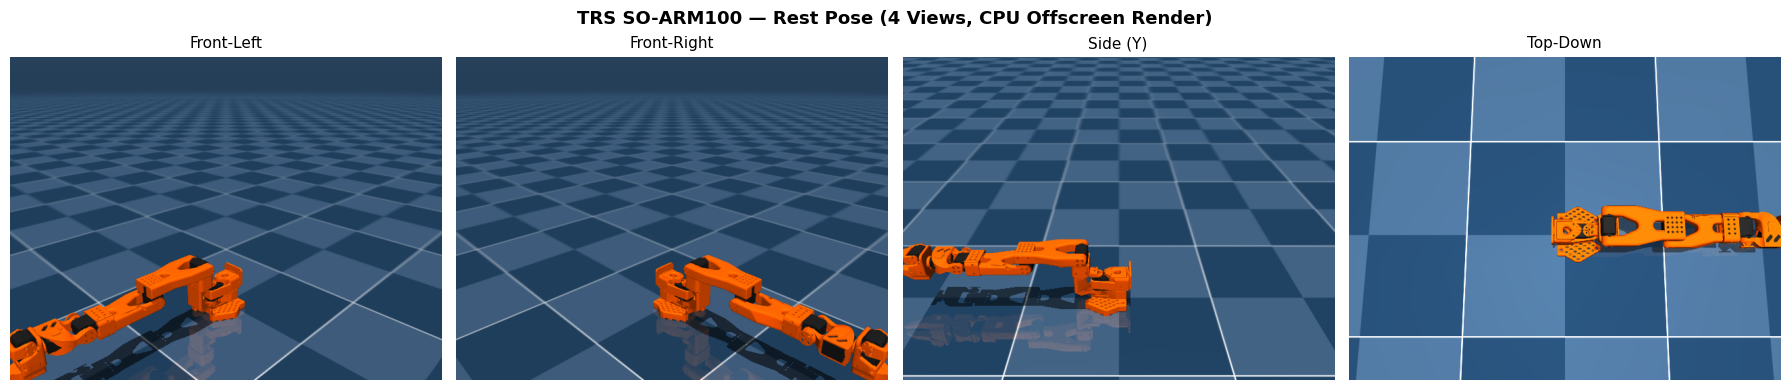

Frame shape: (480, 640, 3)
Saved → so_arm100_views.png


In [34]:
# ── Cell 2: Render single frame, display with matplotlib ─────────────────────
import mujoco
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Reset simulation
mujoco.mj_resetData(model, data)
mujoco.mj_forward(model, data)

# Create renderer
renderer = mujoco.Renderer(model, height=480, width=640)

# Camera angles
VIEWS = [
    dict(azimuth=135, elevation=-20, distance=0.8,  label='Front-Left'),
    dict(azimuth=45,  elevation=-20, distance=0.8,  label='Front-Right'),
    dict(azimuth=180, elevation=-30, distance=0.75, label='Side (Y)'),
    dict(azimuth=0,   elevation=-80, distance=0.6,  label='Top-Down'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, view in zip(axes, VIEWS):
    # Create camera
    cam = mujoco.MjvCamera()
    cam.type = mujoco.mjtCamera.mjCAMERA_FREE
    cam.azimuth = view['azimuth']
    cam.elevation = view['elevation']
    cam.distance = view['distance']
    cam.lookat[:] = [0.0, 0.0, 0.2]

    # Render
    renderer.update_scene(data, camera=cam)
    frame = renderer.render()

    # Plot
    ax.imshow(frame)
    ax.set_title(view['label'], fontsize=11)
    ax.axis('off')

# Title
plt.suptitle(
    'TRS SO-ARM100 — Rest Pose (4 Views, CPU Offscreen Render)',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
save_path = 'so_arm100_views.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'Frame shape: {frame.shape}')
print(f'Saved → {save_path}')

renderer.close()

---
## Cell 3 — Step Simulation 1000 Steps & Plot Joint Positions

Simulation: 1000 steps  |  dt=2.0 ms  |  final time=2.000 s


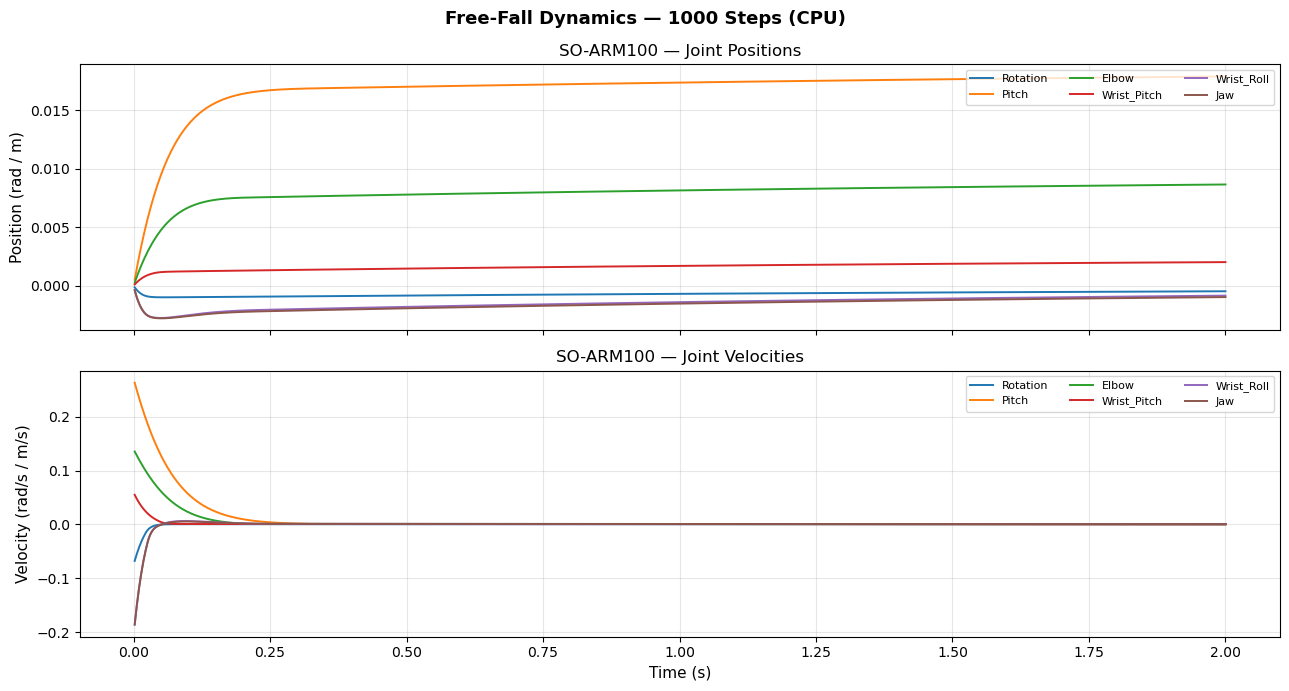

Saved → so_arm100_dynamics.png


In [35]:
# ── Cell 3: Step simulation 1000 steps, plot joint positions ─────────────────
import mujoco
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

mujoco.mj_resetData(model, data)

# Small random push so motion is visible
np.random.seed(42)
data.qvel[:] = np.random.uniform(-0.3, 0.3, model.nv)

N_STEPS = 1000
times   = np.zeros(N_STEPS)
qpos    = np.zeros((N_STEPS, model.nq))
qvel    = np.zeros((N_STEPS, model.nv))

for i in range(N_STEPS):
    mujoco.mj_step(model, data)
    times[i] = data.time
    qpos[i]  = data.qpos.copy()
    qvel[i]  = data.qvel.copy()

print(f'Simulation: {N_STEPS} steps  |  dt={model.opt.timestep*1000:.1f} ms  |  final time={data.time:.3f} s')

# Identify which joints belong to the arm (skip world/floor joints if any)
arm_joints = []
for i in range(model.njnt):
    j = model.joint(i)
    if j.type in [2, 3]:   # slide or hinge
        arm_joints.append((i, j.name))

cmap  = plt.cm.tab10
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

for idx, (qi, jname) in enumerate(arm_joints[:8]):
    ax1.plot(times, qpos[:, qi], label=jname, color=cmap(idx/10), lw=1.4)
    ax2.plot(times, qvel[:, qi], label=jname, color=cmap(idx/10), lw=1.4)

ax1.set_ylabel('Position (rad / m)', fontsize=11)
ax1.set_title('SO-ARM100 — Joint Positions', fontsize=12)
ax1.legend(fontsize=8, ncol=3, loc='upper right')
ax1.grid(True, alpha=0.3)

ax2.set_ylabel('Velocity (rad/s / m/s)', fontsize=11)
ax2.set_xlabel('Time (s)', fontsize=11)
ax2.set_title('SO-ARM100 — Joint Velocities', fontsize=12)
ax2.legend(fontsize=8, ncol=3, loc='upper right')
ax2.grid(True, alpha=0.3)

# Better version (clean + no warning)

plt.suptitle(
    f'Free-Fall Dynamics — {N_STEPS} Steps (CPU)',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()

save_path = 'so_arm100_dynamics.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {save_path}')

---
## Cell 4 — Load Model from MuJoCo Menagerie & Render Named Poses

Model joints: ['Rotation', 'Pitch', 'Elbow', 'Wrist_Pitch', 'Wrist_Roll', 'Jaw']

Mapped joints:  J1=Rotation  J2=Pitch  J3=Elbow  J4=Wrist_Pitch  J5=Wrist_Roll  J6=Jaw
Saved → so_arm100_poses.png


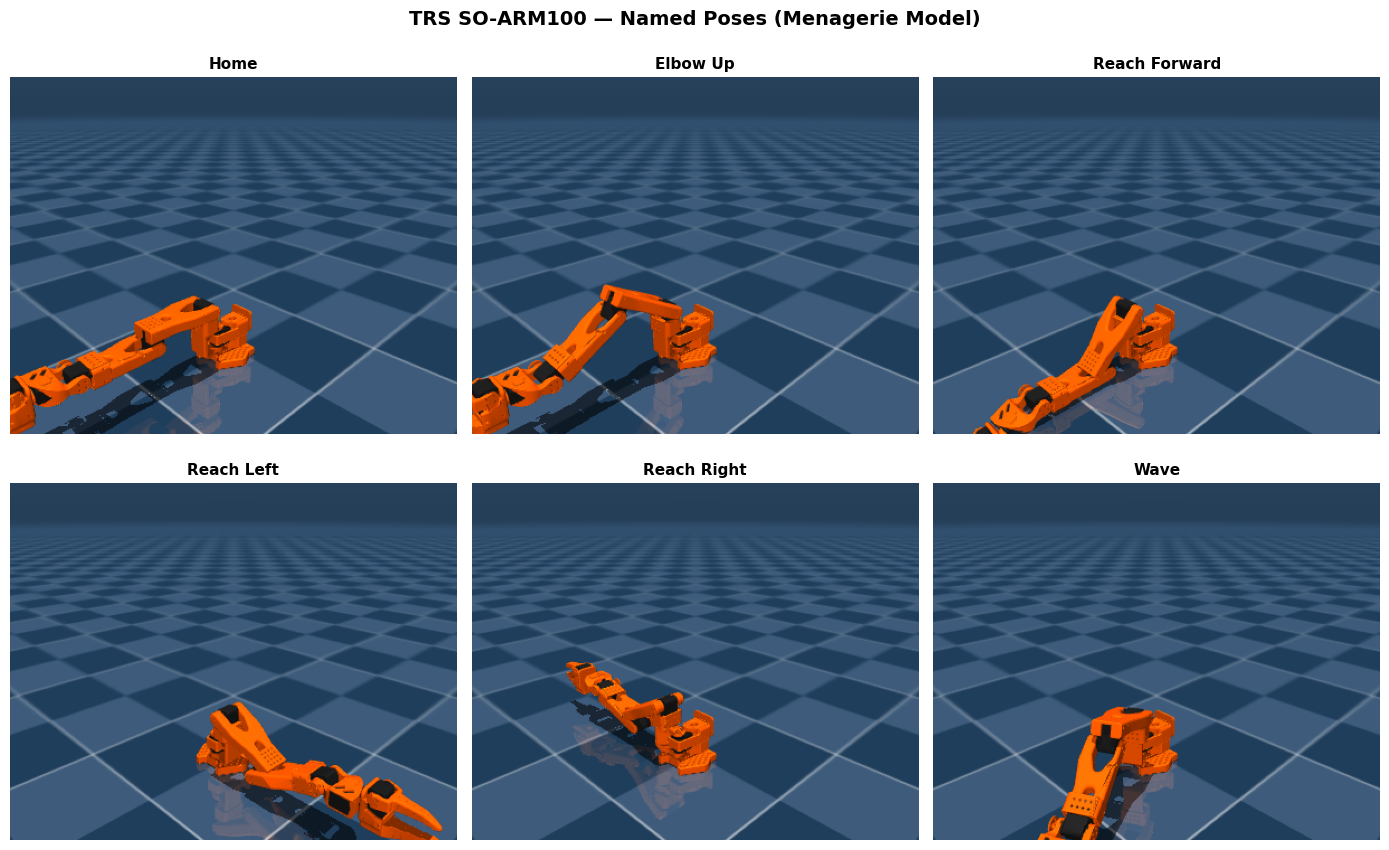

In [37]:
# ── Cell 4: Render named poses using the Menagerie SO-ARM100 ─────────────────
import mujoco
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Helper: build a qpos from a dict of {joint_name: angle_rad}
def make_qpos(model, joint_angles: dict) -> np.ndarray:
    q = np.zeros(model.nq)
    for jname, val in joint_angles.items():
        try:
            jid = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, jname)
            qadr = model.jnt_qposadr[jid]
            q[qadr] = val
        except Exception:
            pass
    return q

# Discover joint names in the model
joint_names = [model.joint(i).name for i in range(model.njnt)]
print('Model joints:', joint_names)

# ── Named poses ───────────────────────────────────────────────────────────────
def find_joint(model, keywords):
    """Find first joint whose name contains any keyword."""
    for kw in keywords:
        for i in range(model.njnt):
            if kw.lower() in model.joint(i).name.lower():
                return model.joint(i).name
    return None

j1 = find_joint(model, ['rotation', 'base', 'joint1', 'j1'])
j2 = find_joint(model, ['pitch', 'shoulder', 'joint2', 'j2'])
j3 = find_joint(model, ['elbow', 'joint3', 'j3'])
j4 = find_joint(model, ['wrist', 'joint4', 'j4'])
j5 = find_joint(model, ['roll', 'joint5', 'j5'])
j6 = find_joint(model, ['jaw', 'gripper', 'finger', 'joint6', 'j6'])

print(f'\nMapped joints:  J1={j1}  J2={j2}  J3={j3}  J4={j4}  J5={j5}  J6={j6}')

POSES = [
    ('Home',          {j1: 0.0,   j2: 0.0,  j3: 0.0,  j4: 0.0,  j5: 0.0}),
    ('Elbow Up',      {j1: 0.0,   j2:-0.5,  j3: 1.0,  j4:-0.5,  j5: 0.0}),
    ('Reach Forward', {j1: 0.0,   j2: 0.8,  j3:-0.8,  j4: 0.5,  j5: 0.0}),
    ('Reach Left',    {j1: 1.57,  j2: 0.5,  j3:-0.8,  j4: 0.3,  j5: 0.0}),
    ('Reach Right',   {j1:-1.57,  j2: 0.5,  j3:-0.8,  j4: 0.3,  j5: 0.0}),
    ('Wave',          {j1: 0.5,   j2:-0.3,  j3: 0.8,  j4:-0.3,  j5: 1.0}),
]

POSES = [
    (name, {k: v for k, v in angles.items() if k is not None})
    for name, angles in POSES
]

renderer = mujoco.Renderer(model, height=320, width=400)
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for ax, (pname, angles) in zip(axes.flat, POSES):
    mujoco.mj_resetData(model, data)
    data.qpos[:] = make_qpos(model, angles)
    mujoco.mj_forward(model, data)

    cam = mujoco.MjvCamera()
    cam.type = mujoco.mjtCamera.mjCAMERA_FREE
    cam.azimuth = 135
    cam.elevation = -20
    cam.distance = 0.8
    cam.lookat[:] = [0.0, 0.0, 0.2]

    renderer.update_scene(data, camera=cam)
    frame = renderer.render()

    ax.imshow(frame)
    ax.set_title(pname, fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle(
    'TRS SO-ARM100 — Named Poses (Menagerie Model)',
    fontsize=14,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('so_arm100_poses.png', dpi=130, bbox_inches='tight')

# If using Agg backend, comment this out
# plt.show()

print('Saved → so_arm100_poses.png')
renderer.close()

---
## Cell 5 — Forward Kinematics & Workspace Visualisation

Using end-effector body: "Wrist_Pitch_Roll" (id=5)

Forward Kinematics — Named Configurations
──────────────────────────────────────────────────────────────────────
Config                     X (m)     Y (m)     Z (m)   Quat [w x y z]
──────────────────────────────────────────────────────────────────────
Home                      0.0000   -0.3233    0.0962   [1.000 0.000 0.000 0.000]
Elbow Up                  0.0000   -0.3089    0.0883   [1.000 0.000 0.000 0.000]
Reach Forward             0.0000   -0.2690    0.0239   [0.969 0.247 0.000 0.000]
Reach Left                0.2433   -0.0454    0.0853   [0.707 0.000 0.000 0.707]
Reach Right              -0.2433   -0.0454    0.0853   [0.707 0.000 -0.000 -0.707]
Wave                      0.1281   -0.2798    0.0654   [0.964 0.097 0.025 0.246]
──────────────────────────────────────────────────────────────────────

Sampling 3000 random configs for workspace cloud...
Workspace X: [-0.278, 0.281] m
Workspace Y: [-0.326, 0.170] m
Workspace Z: [-0.064

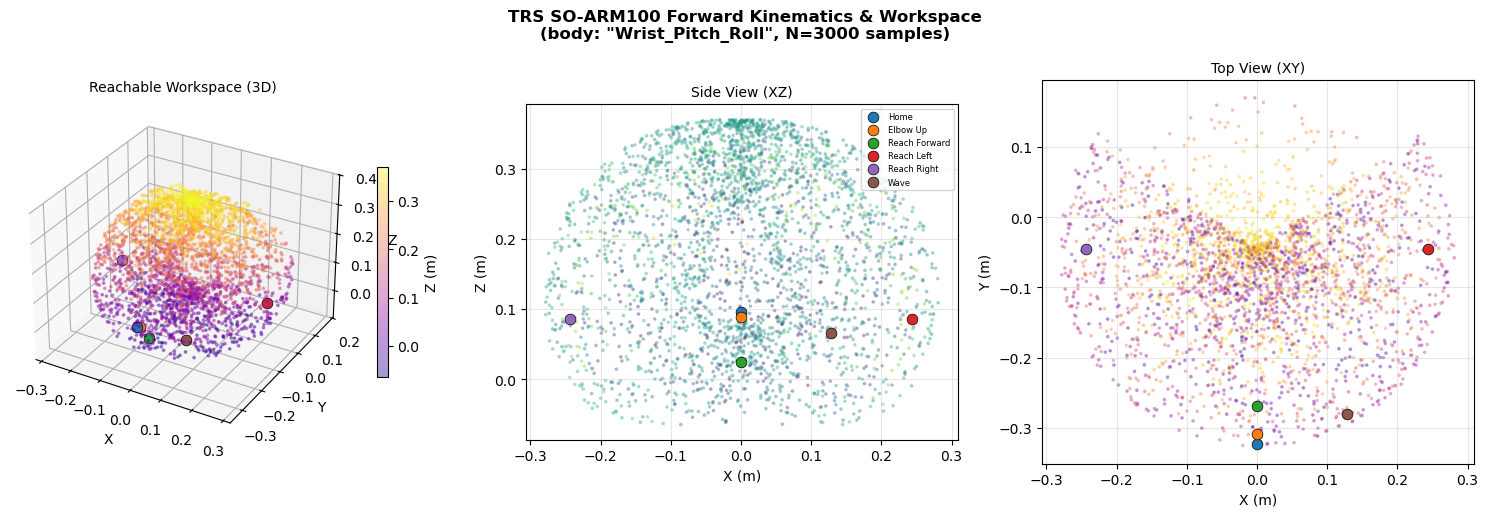

Saved → so_arm100_workspace.png


In [40]:
# ── Cell 5: Forward kinematics — TCP position + workspace scatter ─────────────
import mujoco
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def find_body(model, keywords):
    for kw in keywords:
        for i in range(model.nbody):
            name = model.body(i).name
            if name and kw.lower() in name.lower():
                return i, name
    return -1, None

body_id, body_name = find_body(
    model,
    ['end_effector', 'tcp', 'tool', 'eef', 'tip', 'gripper', 'hand', 'wrist']
)

if body_id < 0:
    print("Available body names:")
    for i in range(model.nbody):
        print(i, model.body(i).name)
    raise RuntimeError(
        "No suitable end-effector body found. Check the printed body names and update keywords."
    )

print(f'Using end-effector body: "{body_name}" (id={body_id})')

print()
print('Forward Kinematics — Named Configurations')
print('─' * 70)
print(f'{"Config":<22} {"X (m)":>9} {"Y (m)":>9} {"Z (m)":>9}   Quat [w x y z]')
print('─' * 70)

named_pts = {}

for pname, angles in POSES:
    mujoco.mj_resetData(model, data)
    data.qpos[:] = make_qpos(model, angles)
    mujoco.mj_forward(model, data)

    pos = data.xpos[body_id].copy()
    mat = data.xmat[body_id].reshape(3, 3)

    q = np.zeros(4)
    mujoco.mju_mat2Quat(q, mat.reshape(-1))

    named_pts[pname] = pos

    print(
        f'{pname:<22} {pos[0]:>9.4f} {pos[1]:>9.4f} {pos[2]:>9.4f}   '
        f'[{q[0]:.3f} {q[1]:.3f} {q[2]:.3f} {q[3]:.3f}]'
    )

print('─' * 70)

# ─── Workspace cloud ─────────────────────────────────────────────────────────
N = 3000
pts = np.zeros((N, 3))

arm_jids = [
    i for i in range(model.njnt)
    if model.joint(i).type in [mujoco.mjtJoint.mjJNT_HINGE, mujoco.mjtJoint.mjJNT_SLIDE]
]

print(f'\nSampling {N} random configs for workspace cloud...')

for k in range(N):
    mujoco.mj_resetData(model, data)

    for ji in arm_jids:
        lo, hi = model.joint(ji).range
        qadr = model.jnt_qposadr[ji]
        data.qpos[qadr] = np.random.uniform(lo, hi)

    mujoco.mj_forward(model, data)
    pts[k] = data.xpos[body_id].copy()

print(f'Workspace X: [{pts[:,0].min():.3f}, {pts[:,0].max():.3f}] m')
print(f'Workspace Y: [{pts[:,1].min():.3f}, {pts[:,1].max():.3f}] m')
print(f'Workspace Z: [{pts[:,2].min():.3f}, {pts[:,2].max():.3f}] m')

# ─── Plot ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 5))
cmap_ws = plt.cm.plasma

# 3D workspace
ax3 = fig.add_subplot(131, projection='3d')
sc = ax3.scatter(
    pts[:, 0], pts[:, 1], pts[:, 2],
    c=pts[:, 2], cmap=cmap_ws, s=3, alpha=0.4
)

for cname, cpos in named_pts.items():
    ax3.scatter(*cpos, s=60, zorder=10, edgecolors='k', linewidths=0.5)

ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_zlabel('Z')
ax3.set_title('Reachable Workspace (3D)', fontsize=10)
plt.colorbar(sc, ax=ax3, shrink=0.5, label='Z (m)')

# XZ side view
ax2 = fig.add_subplot(132)
ax2.scatter(pts[:, 0], pts[:, 2], c=pts[:, 1], cmap='viridis', s=3, alpha=0.3)

for cname, cpos in named_pts.items():
    ax2.scatter(
        cpos[0], cpos[2], s=60, zorder=10, label=cname,
        edgecolors='k', linewidths=0.5
    )

ax2.set_xlabel('X (m)')
ax2.set_ylabel('Z (m)')
ax2.set_title('Side View (XZ)', fontsize=10)
ax2.legend(fontsize=6, loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')

# XY top view
ax4 = fig.add_subplot(133)
ax4.scatter(pts[:, 0], pts[:, 1], c=pts[:, 2], cmap='plasma', s=3, alpha=0.3)

for cname, cpos in named_pts.items():
    ax4.scatter(
        cpos[0], cpos[1], s=60, zorder=10,
        edgecolors='k', linewidths=0.5
    )

ax4.set_xlabel('X (m)')
ax4.set_ylabel('Y (m)')
ax4.set_title('Top View (XY)', fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.set_aspect('equal')

plt.suptitle(
    f'TRS SO-ARM100 Forward Kinematics & Workspace\n'
    f'(body: "{body_name}", N={N} samples)',
    fontsize=12,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('so_arm100_workspace.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → so_arm100_workspace.png')

---
## Bonus — Interactive Joint Sliders

Drag sliders to move joints and see a live rendered image + TCP position.

> Requires `ipywidgets`. Run: `pip install ipywidgets`

In [42]:
# ── BONUS: ipywidgets interactive pose explorer ───────────────────────────────
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    import matplotlib.pyplot as plt
    import mujoco
    import numpy as np

    mujoco.mj_resetData(model, data)
    rnd = mujoco.Renderer(model, height=400, width=580)

    # Find a body to use as end-effector if the model has no site
    def find_body(model, keywords):
        for kw in keywords:
            for i in range(model.nbody):
                name = model.body(i).name
                if name and kw.lower() in name.lower():
                    return i, name
        return -1, None

    # Try site first if it exists
    use_site = False
    site_id = -1
    site_name = None

    if model.nsite > 0:
        for kw in ['end_effector', 'tcp', 'tool', 'eef', 'tip', 'gripper', 'attachment']:
            for i in range(model.nsite):
                sname = model.site(i).name
                if sname and kw.lower() in sname.lower():
                    site_id = i
                    site_name = sname
                    use_site = True
                    break
            if use_site:
                break

        if not use_site:
            site_id = model.nsite - 1
            site_name = model.site(site_id).name
            use_site = True

    body_id = -1
    body_name = None
    if not use_site:
        body_id, body_name = find_body(
            model,
            ['end_effector', 'tcp', 'tool', 'eef', 'tip', 'gripper', 'hand', 'wrist']
        )
        if body_id < 0:
            print("Available body names:")
            for i in range(model.nbody):
                print(i, model.body(i).name)
            raise RuntimeError(
                "No suitable site or body found for the end effector."
            )

    if use_site:
        print(f'Using site: "{site_name}" (id={site_id})')
    else:
        print(f'Using body: "{body_name}" (id={body_id})')

    # Only show arm joints (hinge / slide)
    show_joints = [
        (i, model.joint(i))
        for i in range(model.njnt)
        if model.joint(i).type in [
            mujoco.mjtJoint.mjJNT_HINGE,
            mujoco.mjtJoint.mjJNT_SLIDE
        ]
    ]

    sliders = []
    for ji, j in show_joints:
        lo, hi = float(j.range[0]), float(j.range[1])
        unit = 'm' if j.type == mujoco.mjtJoint.mjJNT_SLIDE else 'rad'
        step = max((hi - lo) / 200, 1e-4)

        s = widgets.FloatSlider(
            min=lo,
            max=hi,
            step=step,
            value=0.0,
            description=f'{j.name[:16]} ({unit})',
            style={'description_width': '155px'},
            layout=widgets.Layout(width='480px'),
            readout_format='.3f'
        )
        sliders.append((ji, j, s))

    out = widgets.Output()

    def update(*args):
        mujoco.mj_resetData(model, data)

        for ji, j, s in sliders:
            qadr = model.jnt_qposadr[ji]
            data.qpos[qadr] = s.value

        mujoco.mj_forward(model, data)

        if use_site:
            pos = data.site_xpos[site_id].copy()
        else:
            pos = data.xpos[body_id].copy()

        cam = mujoco.MjvCamera()
        cam.type = mujoco.mjtCamera.mjCAMERA_FREE
        cam.azimuth = 135
        cam.elevation = -20
        cam.distance = 0.8
        cam.lookat[:] = [0.0, 0.0, 0.2]

        rnd.update_scene(data, camera=cam)
        frame = rnd.render()

        with out:
            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(7, 5))
            ax.imshow(frame)
            ax.set_title(
                f'TCP   X={pos[0]:.4f}  Y={pos[1]:.4f}  Z={pos[2]:.4f} m',
                fontsize=11
            )
            ax.axis('off')
            plt.tight_layout()
            plt.show()

    for _, _, s in sliders:
        s.observe(update, names='value')

    update()
    slider_col = widgets.VBox([s for _, _, s in sliders])
    display(widgets.HBox([slider_col, out]))

except ImportError:
    print('ipywidgets not found. Run: pip install ipywidgets')
    print('Then restart the kernel and re-run this cell.')

Using body: "Wrist_Pitch_Roll" (id=5)
